In [16]:
# please comment out once downloaded once to avoid re-downloading at each run !
# !wget https://perso.liris.cnrs.fr/nicolas.bonneel/diffusion/unets.py
# !wget https://perso.liris.cnrs.fr/nicolas.bonneel/diffusion/fullmodel_unetsmall_faces.pt
# !wget https://perso.liris.cnrs.fr/nicolas.bonneel/diffusion/fullmodel_unetsmall_faces2.pt
# !wget https://perso.liris.cnrs.fr/nicolas.bonneel/diffusion/fullmodel_unetsmall_photos.pt
# !wget https://perso.liris.cnrs.fr/nicolas.bonneel/diffusion/fullmodel_unet_faces.pt


import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import time
from mpl_toolkits.axes_grid1 import ImageGrid
import unets

t_max = 500  # 1000 for unet_faces, 500 for unetsmall_faces, or 200 for the photo dataset

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

model = unets.UNetSmall(image_size=128, in_channels=3, out_channels=3, num_classes=None).to(device)

alpha_t_vec = 1-np.linspace(0.0001, 0.02, t_max)
alpha_bar_t_vec = np.cumprod(alpha_t_vec)

checkpoint = torch.load("./fullmodel_unetsmall_faces.pt", weights_only=True, map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['model_state_dict'])

training = False


if training:
    resize_transform = transforms.Compose([ transforms.Resize(size=(128,128)), transforms.PILToTensor(), transforms.ConvertImageDtype(torch.float32) ]);

    dataset = datasets.ImageFolder(root = "./data",
                             transform = resize_transform)

    loader = torch.utils.data.DataLoader(dataset = dataset,
                                        batch_size = 1,
                                        shuffle = True)
    loss_function = torch.nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)

    prefetched_images = []
    for (image, _) in loader:
        prefetched_images.append(np.squeeze(image*2.0-1.0))

    epochs =  int(2505*12)
    outputs = []
    losses = []
    batch_size = 8

    start_time = time.time()
    for epoch in range(epochs):
        random.shuffle(prefetched_images)

        #for i in range(0, int(4936/batch_size) ):
        for i in range(0, int(48/batch_size) ):
            batch = prefetched_images[(i*batch_size):(i*batch_size+batch_size)]
            image = torch.stack(batch, dim=0)
            img = image.to(device)
            t = np.random.random_integers(0, t_max-1, size=(batch_size))

            eps_0_t = torch.randn(img.size(), device=device)
            alpha_bar_t = torch.from_numpy(alpha_bar_t_vec[t]).to(device=device).view((batch_size, 1, 1, 1)).float()
            noisy_img = torch.sqrt(alpha_bar_t) * img + torch.sqrt(1-alpha_bar_t)*eps_0_t

            predicted_noise_value = model(noisy_img, torch.from_numpy(t).float().to(device=device))

            loss = loss_function(predicted_noise_value, eps_0_t)

            reconstructed = (noisy_img - torch.sqrt(1-alpha_bar_t)*predicted_noise_value)/torch.sqrt(alpha_bar_t)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.cpu().detach())

    print("--- %s seconds ---" % (time.time() - start_time))

    torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss,
                }, "./fullmodel.pt")


    plt.figure(0)

    plt.style.use('fivethirtyeight')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')

    plt.plot(losses[10:])

    # Show noisy images
    fig = plt.figure(1, figsize=(6, 6))
    grid = ImageGrid(fig, 111,
                 nrows_ncols=(4, 4),
                 axes_pad=0.01,
                 )
    for i, (ax, item)  in enumerate(zip(grid, noisy_img.cpu().detach())):
        if i==16:
            break
        item = (np.transpose(item.reshape(3, 128, 128), (1,2,0))+1.0)/2.0
        ax.imshow(item)

    # Show denoised images
    fig = plt.figure(2, figsize=(6, 6))
    grid = ImageGrid(fig, 111,
                 nrows_ncols=(4, 4),
                 axes_pad=0.01,
                 )

    for i, (ax, item) in enumerate(zip(grid , reconstructed.cpu().detach())):
        if i==16:
            break
        item = (np.transpose(item.reshape(3, 128, 128),(1,2,0))+1.0)/2.0
        ax.imshow(item)


### the denoiser has been learnt.

### Now generate an image

noisy_stuff = torch.randn((1,3,128,128), device=device)
plt.figure(figsize=(5, 5))

model.eval()
with torch.no_grad():
  # loop over time and progressively denoise your randn
  for t in range(t_max-1, -1, -1):
    t_vec = torch.tensor([float(t)], device=device)
    # t_vec = torch.from_numpy(np.array([t])).float().to(device=device)
    predicted_noise_value = model(noisy_stuff, t_vec)

    alpha_t = float(alpha_t_vec[t])
    alpha_bar_t = float(alpha_bar_t_vec[t])
    beta_t = 1-alpha_t

    noisy_stuff = (noisy_stuff - (beta_t/np.sqrt(1-alpha_bar_t))*predicted_noise_value)/np.sqrt(alpha_t) 

    sigma_t = np.sqrt(((1 - alpha_bar_t_vec[t-1])/ (1 - alpha_bar_t_vec[t]))*(1 - alpha_t)) if t > 0 else 0
    # sigma_t = np.sqrt(beta_t)
    noisy_stuff += torch.randn_like(noisy_stuff)*sigma_t  if t > 0 else 0
    print("t=", t, "sigma_t=", sigma_t)
    plot = (noisy_stuff.clamp(-1, 1).squeeze().cpu().detach().permute(1, 2, 0).numpy() + 1.0) / 2.0

    # plt.imshow(plot)
    # plt.axis('off')
    # plt.show()

  print("todo")


cpu
t= 499 sigma_t= 0.1414121298873868
t= 498 sigma_t= 0.14127090229268854
t= 497 sigma_t= 0.14112953131730374
t= 496 sigma_t= 0.1409880165105095
t= 495 sigma_t= 0.14084635741929863
t= 494 sigma_t= 0.14070455358836406
t= 493 sigma_t= 0.14056260456008668
t= 492 sigma_t= 0.1404205098745216
t= 491 sigma_t= 0.14027826906938423
t= 490 sigma_t= 0.14013588168003682
t= 489 sigma_t= 0.13999334723947426
t= 488 sigma_t= 0.13985066527831003
t= 487 sigma_t= 0.1397078353247635
t= 486 sigma_t= 0.13956485690464351
t= 485 sigma_t= 0.1394217295413357
t= 484 sigma_t= 0.1392784527557876
t= 483 sigma_t= 0.13913502606649436
t= 482 sigma_t= 0.138991448989484
t= 481 sigma_t= 0.1388477210383029
t= 480 sigma_t= 0.13870384172400024
t= 479 sigma_t= 0.13855981055511515
t= 478 sigma_t= 0.13841562703765886
t= 477 sigma_t= 0.13827129067510144
t= 476 sigma_t= 0.1381268009683559
t= 475 sigma_t= 0.13798215741576292
t= 474 sigma_t= 0.1378373595130753
t= 473 sigma_t= 0.13769240675344185
t= 472 sigma_t= 0.13754729862739332

<Figure size 500x500 with 0 Axes>

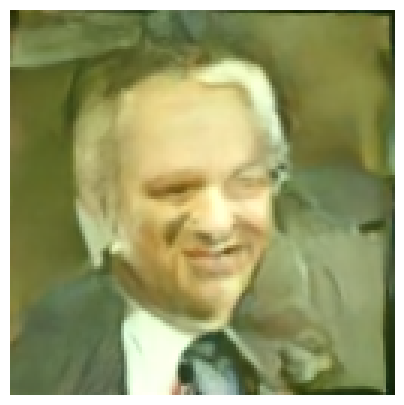

In [17]:
# plot = (noisy_stuff.clamp(-1, 1).squeeze().cpu().detach().numpy().transpose(1, 2, 0) + 1.0) / 2.0
plot = (noisy_stuff.clamp(-1, 1).squeeze().cpu().detach().permute(1, 2, 0).numpy() + 1.0) / 2.0

plt.figure(figsize=(5, 5))
plt.imshow(plot)
plt.axis('off')
plt.show()